In [3]:
import torch 
from src.utils import data_config_map, DataType, NeuralOperatorDataset
import json
from src.models import NeuralOperatorModel, ModelType

import matplotlib.pyplot as plt


In [6]:

model_name = "ss_burgers_psr"

with open(f'./models/{model_name}.json') as f:
    d = json.load(f)

print(d)

data_type = DataType(d["data"])
# data_config = data_config_map.get(data_type)

# cheby = False if d["model"] == "fno" else True 
# pth = data_config.pth if cheby is False else data_config.cheby_pth

# data = torch.load(pth, mmap=True)

data = NeuralOperatorDataset(data_type, 
                            is_cheby=False if d["model"] == "fno" else True, 
                            ntrain=d["ntrain"],
                            ntest=d["ntest"], 
                            batch_size=d["batch_size"], 
                            normalize=d["normalize"],
                            subsample=d["subsample"])


model_params = {k: eval(v) for k, v in (arg.split('=') for arg in d["arg"])}
model = NeuralOperatorModel(ModelType(d["model"]), data=data_type, **model_params)

model.load_state_dict(torch.load(f"./models/{model_name}.pt", map_location=torch.device('cpu')))


{'model': 'ss', 'data': 'burgers_psr', 'run_name': 'ss_burgers_psr', 'project_name': 'ultranet_bpsr', 'subsample': 1, 'arg': ['modes=12', 'width=16', 'rank=4', 'nbc=4'], 'nepochs': 500, 'ntrain': 1000, 'ntest': 200, 'batch_size': 4, 'normalize': False, 'nparams': 297953}


<All keys matched successfully>

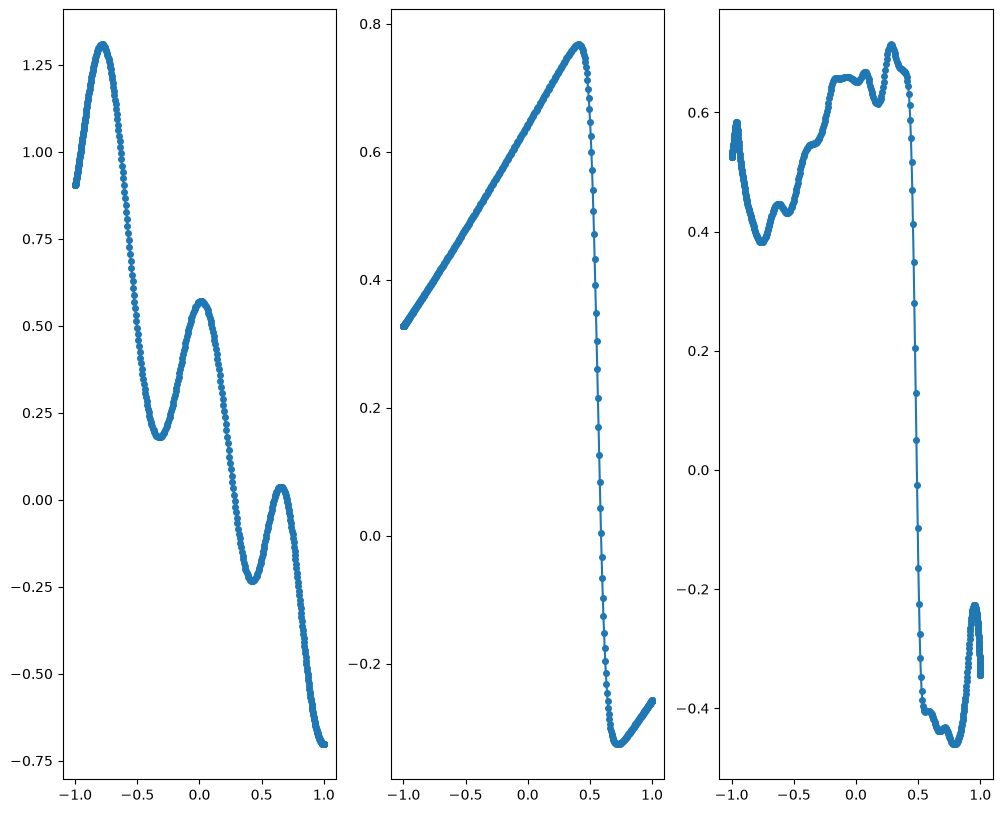

In [7]:
def visualize_output(model: NeuralOperatorModel, data: NeuralOperatorDataset):
    a, u = next(iter(data.test_loader))
    a, u = a[0:1], u[0:1]
    if data_type == DataType.BURGERS or DataType.BURGERS_PERIODIC or DataType.BURGERS_PSROBIN:
        out = model(a).detach().numpy()

        grid = a[... , 1:]
        
        fig, axs = plt.subplots(1, 3, figsize=(12, 10))
        markevery = 1
        axs[0].plot(grid[0], a[0,..., 0:1], 'o', ls='-', ms=4, markevery=markevery)
        axs[1].plot(grid[0], u[0], 'o', ls='-', ms=4, markevery=markevery)
        axs[2].plot(grid[0], out[0], 'o', ls='-', ms=4, markevery=markevery)

        plt.show()
        

visualize_output(model, data=data)
